# Inspecting Temperature and Chemistry Profiles

A spectrum is the end product of a model, but the underlying vertical structure often explains the result more clearly than the spectrum itself. This notebook turns the emphasis around: we inspect the temperature and composition profiles first, then think about what those profiles imply for an emission calculation.

The example uses a Guillot temperature profile so the atmosphere is no longer perfectly isothermal.

In [6]:
from _shared import build_emission_model
from taurex.temperature import Guillot2010

temperature_profile = Guillot2010(T_irr=1500)
context = build_emission_model(temperature_profile=temperature_profile, download=False)
temperature_profile.initialize_profile(
    planet=context['planet'],
    nlayers=context['press'].nLayers,
    pressure_profile=context['press'].profile,
)
em = context['em']

print(type(temperature_profile).__name__)
print('Gases:', em.chemistry.gases)

Guillot2010
Gases: ['H2', 'He', 'H2O', 'CH4', 'NH3', 'CO2']


The first step is to make the temperature profile explicit rather than hiding it inside a helper call. That makes it easier to connect the profile object itself to the plots that follow.

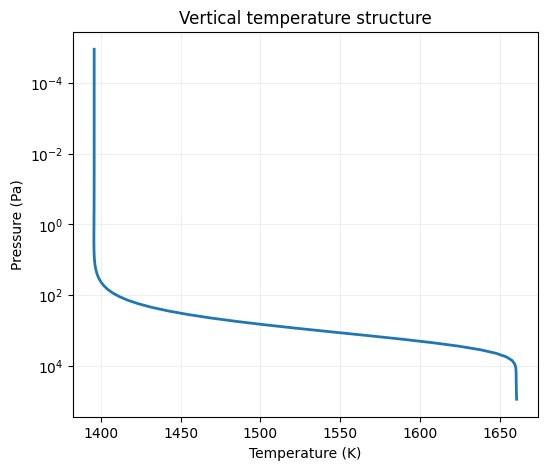

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(em.temperatureProfile, em.pressureProfile, lw=2)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
plt.title('Vertical temperature structure')
plt.grid(alpha=0.2)

The temperature plot is where the notebook becomes physical rather than procedural. You are no longer asking only whether TauREx runs, but what kind of atmosphere you have actually built.

When reading this figure, think in terms of which pressures dominate the emergent flux. Any curvature or inversion in the profile can change whether features appear in absorption-like or emission-like contrast.

Temperature range: 1395.7 K to 1660.4 K


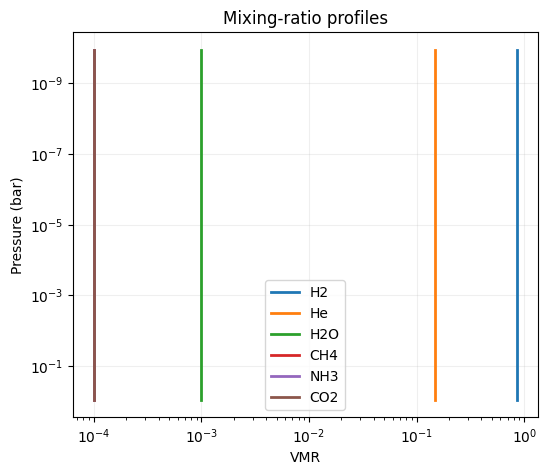

In [8]:
plt.figure(figsize=(6, 5))
for index, gas_name in enumerate(em.chemistry.gases):
    plt.plot(em.chemistry.mixProfile[index], em.pressureProfile / 1e5, label=gas_name, lw=2)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('VMR')
plt.ylabel('Pressure (bar)')
plt.title('Mixing-ratio profiles')
plt.legend()
plt.grid(alpha=0.2)

print(f'Temperature range: {em.temperatureProfile.min():.1f} K to {em.temperatureProfile.max():.1f} K')

The chemistry plot answers a different question from the temperature plot. Instead of asking how thermal structure changes with pressure, it asks which absorbers are available at each depth to imprint on the spectrum.